# 4. Ensembles de Arboles de Decision

Un arbol de decisión es un modelo débil, el aumento del poder predictivo proviene al ensamblar varios arboles de decisión.
<br> Si promedio n arboles identicos, el resultados es exactamente el mismo que utilizar un solo arbol, necesito PERTURBAR cada arbol para disponer de variablidad

la variabilidad provendrá de estas fuentes:


*   Perturbar el dataset
*   Perturbar el algoritmo del arbol
*   Perturbar el dataset y el algoritmo del arbol al mismo tiempo

Se verán estos tres algoritmos


*   Arboles Azarosos
*   Random Forest
*   Gradient Boosting of Decision Trees

#### 4.01 Seteo del ambiente en Google Colab

Esta parte se debe correr con el runtime en Python3
<br>Ir al menu, Runtime -> Change Runtime Type -> Runtime type ->  **Python 3**

Conectar la virtual machine donde esta corriendo Google Colab con el  Google Drive, para poder tener persistencia de archivos

In [1]:
# primero establecer el Runtime de Python 3
from google.colab import drive
drive.mount('/content/.drive')

Drive already mounted at /content/.drive; to attempt to forcibly remount, call drive.mount("/content/.drive", force_remount=True).


Para correr la siguiente celda es fundamental en Arranque en Frio haber copiado el archivo kaggle.json al Google Drive, en la carpeta indicada en el instructivo

<br>los siguientes comando estan en shell script de Linux
*   Crear las carpetas en el Google Drive
*   "instalar" el archivo kaggle.json desde el Google Drive a la virtual machine para que pueda ser utilizado por la libreria  kaggle de Python
*   Bajar el  **dataset_pequeno**  al  Google Drive  y tambien al disco local de la virtual machine que esta corriendo Google Colab



In [2]:
%%shell

mkdir -p "/content/.drive/My Drive/dmeyf"
mkdir -p "/content/buckets"
ln -sfn "/content/.drive/My Drive/dmeyf"   /content/buckets/b1

mkdir -p ~/.kaggle
cp /content/buckets/b1/kaggle/kaggle.json  ~/.kaggle
chmod 600 ~/.kaggle/kaggle.json


mkdir -p /content/buckets/b1/exp
mkdir -p /content/buckets/b1/datasets
mkdir -p /content/datasets


# defino funcion descargar()
descargar() {
  carpeta_destino="/content/buckets/b1/datasets/"
  url_origen="https://storage.googleapis.com/open-courses/utn2026-b40a/"
  archivo="$1"

  if ! test -f "$carpeta_destino""$archivo"; then
    wget  "$url_origen""$archivo"  -O "$carpeta_destino""$archivo"
  fi

  if ! test -f  "/content/datasets/""$archivo"; then
    cp  "$carpeta_destino""$archivo"  "/content/datasets/""$archivo"
  fi;
}

# hago la descarga efectiva, llamando a descargar()
descargar  "dataset_pequeno.csv"



---



## 4.02 Arboles Azarosos

Arboles Azarosos es el nombre de un algoritmo trivial (por favor NO confundir con Random Forest)
Qué tipo de perturbaciones se realizan en Arboles Azarosos
* Se perturba el dataset
* No se perturba el algoritmo, es siempre rpart original

Cada  arbolito de  Arboles Azarosos se entrena sobre un dataset perturbado,  que tiene exactamente la misma cantidad de registros pero solo un subconjunto de los atributos (campos)  del dataset, tomados al azar, de los originales.
<br> En esta primera corrida, se construira cada arbol en un dataset utilizando el 50% de los campos

Esta parte se debe correr con el runtime en lenguaje **R** Ir al menu, Runtime -> Change Runtime Type -> Runtime type -> R

limpio el ambiente de R

In [1]:
format(Sys.time(), "%a %b %d %X %Y")

[1] "Mon Aug 24 12:38:04 PM 2026"

In [2]:
# limpio la memoria
rm(list=ls(all.names=TRUE)) # remove all objects
gc(full=TRUE, verbose=FALSE) # garbage collection

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,671287,35.9,1473300,78.7,1473300,78.7
Vcells,1242646,9.5,8388608,64.0,1978712,15.1


In [3]:
# cargo las librerias que necesito
require("data.table")
require("rpart")

Loading required package: data.table


Attaching package: ‘data.table’


The following object is masked from ‘package:base’:

    %notin%


Loading required package: rpart



Aqui debe cargar SU semilla primigenia

In [4]:
"""
PARAM <- list()
PARAM$semilla_primigenia <- 378089

# parametros  arbol
# entreno cada arbol con solo 50% de las variables variables
#  por ahora, es fijo
PARAM$feature_fraction <- 0.5

PARAM$rpart$cp <- -1
PARAM$rpart$minsplit <- 500
PARAM$rpart$minbucket <- 180
PARAM$rpart$maxdepth <- 7

# voy a generar 512 arboles,
#  a mas arboles mas tiempo de proceso y MEJOR MODELO,
#  pero ganancias marginales
PARAM$num_trees_max <- 512
"""

ERROR: Error in parse(text = input): <text>:1:3: unexpected string constant
18: PARAM$num_trees_max <- 512
19: "
      ^


In [4]:
# nueva celda

PARAM <- list()
PARAM$semilla_primigenia <- 378089

# PAra identificar corrida con nueva grilla
PARAM$tag_experimento <- "colab_v2"
PARAM$competencia <- "utn-2026-inicial"

# ahora son rangos a explorar, no valores fijos
PARAM$rango_feature_fraction <- c(0.5 )
PARAM$rango_minsplit         <- c(200,400, 500, 600, 700)
PARAM$rango_minbucket        <- c(50,100, 150, 175)
PARAM$rango_maxdepth         <- c(10, 12, 14)

PARAM$cp_fijo <- -1   # se mantiene fijo, no se itera

# voy a generar 32 arboles por cada combinacion de hiperparametros
PARAM$num_trees_max <- 32

In [5]:
# carpeta de trabajo
setwd("/content/buckets/b1/exp")
experimento <- "exp420_32_g2"     # <<< carpeta nueva
dir.create(experimento, showWarnings = FALSE)
setwd(paste0("/content/buckets/b1/exp/", experimento))

PARAM$tag_experimento <- "colab_v2"   # el tag sigue siendo importante para el analisis despues

In [6]:
# lectura del dataset
dataset <- fread("/content/datasets/dataset_pequeno.csv")

In [7]:
# defino los dataset de entrenamiento y aplicacion
dtrain <- dataset[foto_mes == 202107]
dfuture <- dataset[foto_mes == 202109]

# arreglo clase_ternaria por algun distraido ""
dfuture[, clase_ternaria := NA ]

In [8]:
# Establezco cuales son los campos que puedo usar para la prediccion
# el copy() es por la Lazy Evaluation
campos_buenos <- copy(setdiff(colnames(dtrain), c("clase_ternaria")))

In [10]:
# que tamanos de ensemble grabo a disco
# grabar <- c(1, 2, 4, 8, 16, 32, 64, 128, 256, 384, 512)

In [11]:
# tb_prediccion <- dfuture[, list(numero_de_cliente)]
# aqui se va acumulando la probabilidad del ensemble
# tb_prediccion[, prob_acumulada := 0]

In [12]:
# set.seed(PARAM$semilla_primigenia) # Establezco la semilla aleatoria

In [13]:
"""
for (arbolito in seq(PARAM$num_trees_max) ) {
  message( arbolito, " ")
  qty_campos_a_utilizar <- as.integer(length(campos_buenos)
    * PARAM$feature_fraction)

  # elijo los campos al azar
  campos_random <- sample(campos_buenos, qty_campos_a_utilizar)

  # paso de un vector a un string con los elementos
  # separados por un signo de "+"
  # este hace falta para la formula
  campos_random <- paste(campos_random, collapse= " + ")

  # armo la formula para rpart
  formulita <- paste0("clase_ternaria ~ ", campos_random)

  # genero el arbol de decision
  modelo <- rpart(formulita,
    data= dtrain,
    xval= 0,
    control= PARAM$rpart
  )

  # aplico el modelo a los datos que no tienen clase
  prediccion <- predict(modelo, dfuture, type= "prob")

  tb_prediccion[, prob_acumulada := prob_acumulada + prediccion[, "BAJA+2"]]

  if (arbolito %in% grabar) {
    umbral_corte <- (1 / 40) * arbolito
    tb_prediccion[, Predicted := as.numeric(prob_acumulada > umbral_corte)]

    archivo_kaggle <- paste0(
        "KA420_",
        sprintf("%.3d", arbolito), # para que tenga ceros adelante
        ".csv"
      )

    # grabo el archivo
    fwrite( tb_prediccion[, list(numero_de_cliente, Predicted)],
      file= archivo_kaggle,
      sep= ","
    )

    # subida a Kaggle
    comando <- "kaggle competitions submit"
    competencia <- "-c utn-2026-inicial"
    arch <- paste( "-f", archivo_kaggle)

    mensaje <- paste0("-m 'cp=", PARAM$rpart$cp, "  minsplit=", PARAM$rpart$minsplit, "  minbucket=", PARAM$rpart$minbucket, " maxdepth=", PARAM$rpart$maxdepth, "'" )
    linea <- paste( comando, competencia, arch, mensaje)
    salida <- system(linea, intern=TRUE)
    cat(salida)
  }
}
"""

ERROR: Error in parse(text = input): <text>:1:3: unexpected string constant
2: for (arbolito in seq(PARAM$num_trees_max) ) {
3:   message( arbolito, "
     ^


In [9]:
# armar la grilla y persistirla
archivo_grilla <- paste0("grilla_hiperparams_", PARAM$tag_experimento, ".RDS")  # <<< nombre distinto

if (file.exists(archivo_grilla)) {

  grilla_hiperparams <- readRDS(archivo_grilla)
  cat("Grilla existente cargada.",
      sum(grilla_hiperparams$estado == "pendiente"), "pendientes de",
      nrow(grilla_hiperparams), "totales.\n")

} else {

  grilla_hiperparams <- CJ(
    feature_fraction = PARAM$rango_feature_fraction,
    minsplit          = PARAM$rango_minsplit,
    minbucket         = PARAM$rango_minbucket,
    maxdepth          = PARAM$rango_maxdepth
  )

  grilla_hiperparams <- grilla_hiperparams[minsplit >= 2 * minbucket]

  grilla_hiperparams[, cp := PARAM$cp_fijo]
  grilla_hiperparams[, id := .I]
  grilla_hiperparams[, tag := PARAM$tag_experimento]
  grilla_hiperparams[, estado := "pendiente"]

  saveRDS(grilla_hiperparams, archivo_grilla)
  cat("Grilla nueva creada con", nrow(grilla_hiperparams), "combinaciones validas.\n")
}


Grilla existente cargada. 43 pendientes de 54 totales.


In [15]:
# función que entrena UN ensemble de 32 árboles
# para UNA combinación de hiperparámetros y sube a Kaggle

generar_y_subir <- function(feature_fraction, vcp, minsplit, minbucket, maxdepth, id_combo, tag) {

  tb_prediccion <- dfuture[, list(numero_de_cliente)]
  tb_prediccion[, prob_acumulada := 0]

  control_arbol <- list(cp = vcp, minsplit = minsplit, minbucket = minbucket, maxdepth = maxdepth)
  set.seed(PARAM$semilla_primigenia)

  for (arbolito in seq(PARAM$num_trees_max)) {
    qty_campos_a_utilizar <- as.integer(length(campos_buenos) * feature_fraction)
    campos_random <- sample(campos_buenos, qty_campos_a_utilizar)
    formulita <- paste0("clase_ternaria ~ ", paste(campos_random, collapse = " + "))

    modelo <- rpart(formulita, data = dtrain, xval = 0, control = control_arbol)
    prediccion <- predict(modelo, dfuture, type = "prob")
    tb_prediccion[, prob_acumulada := prob_acumulada + prediccion[, "BAJA+2"]]
  }

  tb_prediccion[, prob_promedio := prob_acumulada / PARAM$num_trees_max]
  tb_prediccion[, Predicted := as.numeric(prob_promedio > 0.025)]

  archivo_kaggle <- paste0("KA420_", tag, "_combo", sprintf("%.4d", id_combo), ".csv")
  fwrite(tb_prediccion[, list(numero_de_cliente, Predicted)], file = archivo_kaggle, sep = ",")

  mensaje <- paste0("-m 'tag=", tag,
                     " id=", id_combo,
                     " ff=", feature_fraction,
                     " cp=", vcp,
                     " minsplit=", minsplit,
                     " minbucket=", minbucket,
                     " maxdepth=", maxdepth, "'")

  linea <- paste("kaggle competitions submit -c", PARAM$competencia,
                  "-f", archivo_kaggle, mensaje)

  salida <- system(linea, intern = TRUE)
  status <- attr(salida, "status")
  cat(salida, "\n")

  # <<< NUEVO: si el comando fallo, lanzo un error real para que el tryCatch lo capture
  if (!is.null(status) && status != 0) {
    stop(paste("Fallo el submit a Kaggle (status", status, "):", paste(salida, collapse = " ")))
  }
}

In [ ]:
# loop principal
# solo procesa lo "pendiente", guarda checkpoint tras cada submit

pendientes <- which(grilla_hiperparams$estado == "pendiente")

for (i in pendientes) {

  fila <- grilla_hiperparams[i]

  cat("\nCombinacion", fila$id, "(", fila$tag, ") / ", nrow(grilla_hiperparams),
      " | ff=", fila$feature_fraction, " minsplit=", fila$minsplit,
      " minbucket=", fila$minbucket, " maxdepth=", fila$maxdepth, "\n")

  resultado_ok <- tryCatch({
    generar_y_subir(
      feature_fraction = fila$feature_fraction,
      vcp              = fila$cp,
      minsplit         = fila$minsplit,
      minbucket        = fila$minbucket,
      maxdepth         = fila$maxdepth,
      id_combo         = fila$id,
      tag              = fila$tag
    )
    TRUE
  }, error = function(e) {
    cat("  ERROR:", conditionMessage(e), "\n")
    FALSE
  })

  if (resultado_ok) {
    grilla_hiperparams[id == fila$id, estado := "subido"]
    saveRDS(grilla_hiperparams, archivo_grilla)
  } else {
    cat("\n  Cortando el loop.\n")
    break
  }

  Sys.sleep(2)
}

In [ ]:
format(Sys.time(), "%a %b %d %X %Y")

In [10]:
pendientes <- which(grilla_hiperparams$estado == "pendiente")
fila_sospechosa <- grilla_hiperparams[pendientes[1]]
print(fila_sospechosa)

t0 <- Sys.time()
control_prueba <- list(cp = fila_sospechosa$cp, minsplit = fila_sospechosa$minsplit,
                        minbucket = fila_sospechosa$minbucket, maxdepth = fila_sospechosa$maxdepth)

modelo_prueba <- rpart("clase_ternaria ~ .", data = dtrain, xval = 0, control = control_prueba)

cat("Tiempo para 1 arbol:", round(as.numeric(difftime(Sys.time(), t0, units="secs")), 1), "seg\n")
cat("Nodos del arbol:", nrow(modelo_prueba$frame), "\n")

Key: <feature_fraction, minsplit, minbucket, maxdepth>
   feature_fraction minsplit minbucket maxdepth    id      tag    estado    cp
              <num>    <num>     <num>    <num> <int>   <char>    <char> <num>
1:              0.5      400       100       14    12 colab_v2 pendiente    -1


# Subir los csv generados y no subidos

In [ ]:
archivos_generados <- list.files(pattern = "KA420_colab_v2_combo[0-9]+\\.csv")
ids_con_csv <- as.integer(gsub(".*combo([0-9]+)\\.csv", "\\1", archivos_generados))

cat("CSVs ya generados en disco:", length(ids_con_csv), "\n")
print(sort(ids_con_csv))

pendientes_con_csv <- grilla_hiperparams[id %in% ids_con_csv & estado == "pendiente"]
cat("De esos, pendientes de subir:", nrow(pendientes_con_csv), "\n")

for (i in seq_len(nrow(pendientes_con_csv))) {
  fila <- pendientes_con_csv[i]

  archivo_kaggle <- paste0("KA420_", fila$tag, "_combo", sprintf("%.4d", fila$id), ".csv")

  mensaje <- paste0("-m 'tag=", fila$tag,
                     " id=", fila$id,
                     " ff=", fila$feature_fraction,
                     " cp=", fila$cp,
                     " minsplit=", fila$minsplit,
                     " minbucket=", fila$minbucket,
                     " maxdepth=", fila$maxdepth, "'")

  linea <- paste("kaggle competitions submit -c", PARAM$competencia,
                  "-f", archivo_kaggle, mensaje)

  salida <- system(linea, intern = TRUE)
  status <- attr(salida, "status")
  cat(salida, "\n")

  if (is.null(status) || status == 0) {
    grilla_hiperparams[id == fila$id, estado := "subido"]
    saveRDS(grilla_hiperparams, archivo_grilla)
    cat("  -> OK, id", fila$id, "subido\n")
  } else {
    cat("  -> FALLO id", fila$id, ", deteniendo\n")
    break
  }

  Sys.sleep(2)
}

table(grilla_hiperparams$estado)

In [ ]:
# reviso que dice la grilla actualmente
table(grilla_hiperparams$estado)
print(grilla_hiperparams[id %in% 1:15])

In [ ]:
cat("PARAM$competencia: '", PARAM$competencia, "'\n", sep="")

In [ ]:
raw <- system("kaggle competitions submissions -c utn-2026-inicial -v --page-size 200", intern = TRUE)
raw <- raw[!grepl("^Warning", raw)]
subs_check <- fread(paste(raw, collapse = "\n"), header = TRUE, fill = TRUE)

# busco si aparece ALGUNA combinacion de colab_v2 en el historial real
subs_check[grepl("colab_v2", fileName)]

In [ ]:
# si el chequeo anterior confirmo que NO hay ninguna colab_v2 en Kaggle:
grilla_hiperparams[id %in% 1:11, estado := "pendiente"]
saveRDS(grilla_hiperparams, archivo_grilla)

table(grilla_hiperparams$estado)

In [ ]:
grilla_hiperparams[id %in% 1:11, estado := "pendiente"]
saveRDS(grilla_hiperparams, archivo_grilla)

table(grilla_hiperparams$estado)

# Extraccion de datos de KAGGLE

In [13]:
# ============================================================
# 1. Traer el historial completo de submissions desde Kaggle
# ============================================================
nombre_competencia <- "utn-2026-inicial"

submissions_raw <- system(
  paste0("kaggle competitions submissions -c ", nombre_competencia, " -v --page-size 200"),
  intern = TRUE
)

# saco lineas de warning que rompen el parseo
submissions_raw <- submissions_raw[!grepl("^Warning", submissions_raw)]

submissions <- fread(paste(submissions_raw, collapse = "\n"), header = TRUE, fill = TRUE)

cat("Total de submissions en el historial:", nrow(submissions), "\n")
print(names(submissions))

# ============================================================
# 2. Filtrar solo los submits de este experimento (cualquiera de los 3 formatos)
# ============================================================
submissions_experimento <- submissions[grepl("^KA420_", fileName)]
cat("Submissions del experimento (KA420_*):", nrow(submissions_experimento), "\n")

submissions_experimento[, publicScore := as.numeric(publicScore)]

# ============================================================
# 3. Extraer el id desde la descripcion (funciona para los 3 formatos,
#    porque el mensaje "-m" siempre incluyo "id=NN ..." en algun momento)
# ============================================================
submissions_experimento[, id := as.integer(gsub(".*id=([0-9]+).*", "\\1", description))]

# ============================================================
# 4. Asignar el tag segun el patron del nombre de archivo:
#    - KA420_combo*        -> corrida local, grilla original (sin tag en el mensaje)
#    - KA420_colab_v2_combo* -> corrida colab, grilla nueva (tag="colab_v2" en el mensaje)
#    - KA420_32*           -> corrida colab, grilla original (sin tag en el mensaje)
# ============================================================

# primero intento leer el tag directamente del mensaje (para colab_v2, que si lo tiene)
submissions_experimento[, tag := gsub(".*tag=([a-zA-Z0-9_]+).*", "\\1", description)]

# si el regex de arriba no encontro "tag=" en el mensaje, devuelve la descripcion completa sin cambios
# -> lo detecto y lo reemplazo por NA para despues asignarlo segun el nombre de archivo
submissions_experimento[!grepl("tag=", description), tag := NA_character_]

# asigno el tag para los formatos viejos, segun el patron de archivo
submissions_experimento[is.na(tag) & grepl("^KA420_combo", fileName), tag := "local_v1"]
submissions_experimento[is.na(tag) & grepl("^KA420_32", fileName), tag := "colab_v1"]

cat("\nDistribucion de submits por tag:\n")
print(table(submissions_experimento$tag, useNA = "ifany"))

# ============================================================
# 5. Chequeos de calidad antes de cruzar
# ============================================================
submissions_validas <- submissions_experimento[!is.na(id) & !is.na(tag)]
cat("\nSubmissions con id y tag validos:", nrow(submissions_validas), "de", nrow(submissions_experimento), "\n")

# duplicados dentro de la MISMA combinacion tag+id (no deberia haber)
dup_check <- submissions_validas[, .N, by = .(tag, id)][N > 1]
if (nrow(dup_check) > 0) {
  cat("\nATENCION: hay combinaciones tag+id duplicadas:\n")
  print(dup_check)
} else {
  cat("Sin duplicados de tag+id. \n")
}

# ============================================================
# 6. Cargar ambas grillas y unirlas en una sola tabla maestra
# ============================================================
grilla_local <- readRDS("grilla_hiperparams.RDS")           # grilla original (local_v1 + colab_v1)
# grilla_local[, tag_real := ifelse(origen == "local", "local_v1", "colab_v1")]
# si tu grilla original no tiene columna "origen", comenta la linea de arriba y usa:
grilla_local[, tag_real := "local_v1"]  # o el criterio que corresponda

grilla_colab_v2 <- readRDS("grilla_hiperparams_colab_v2.RDS")
grilla_colab_v2[, tag_real := tag]  # esta grilla ya tiene su propia columna tag

# unifico columnas antes del rbind (ajustar nombres si difieren)
cols_comunes <- c("id", "feature_fraction", "minsplit", "minbucket", "maxdepth", "cp", "tag_real")

grilla_maestra <- rbind(
  grilla_local[, ..cols_comunes],
  grilla_colab_v2[, ..cols_comunes]
)
setnames(grilla_maestra, "tag_real", "tag")

cat("\nGrilla maestra consolidada:", nrow(grilla_maestra), "combinaciones totales\n")

# ============================================================
# 7. Cruzar la grilla maestra con los scores de Kaggle
# ============================================================
resultados_kaggle <- merge(
  grilla_maestra,
  submissions_validas[, list(tag, id, publicScore, status, date)],
  by = c("tag", "id"),
  all.x = TRUE
)

resultados_kaggle <- resultados_kaggle[order(-publicScore)]

fwrite(resultados_kaggle, "resultados_kaggle_consolidado.csv")

print(resultados_kaggle[1:15])
cat("\nCon score valido:", sum(!is.na(resultados_kaggle$publicScore)),
    "de", nrow(resultados_kaggle), "combinaciones totales\n")

Total de submissions en el historial: 136 
[1] "fileName"     "date"         "description"  "status"       "publicScore" 
[6] "privateScore"
Submissions del experimento (KA420_*): 129 


Warning message in eval(jsub, SDenv, parent.frame()):
“NAs introduced by coercion”



Distribucion de submits por tag:

colab_v1 colab_v2 local_v1     <NA> 
      61       11       46       11 

Submissions con id y tag validos: 118 de 129 
Sin duplicados de tag+id. 

Grilla maestra consolidada: 198 combinaciones totales
         tag    id feature_fraction minsplit minbucket maxdepth    cp
      <char> <int>            <num>    <num>     <num>    <num> <num>
 1: colab_v2     3              0.5      200        50       14    -1
 2: colab_v2     2              0.5      200        50       12    -1
 3: colab_v2     1              0.5      200        50       10    -1
 4: colab_v2     8              0.5      400        50       12    -1
 5: colab_v2     9              0.5      400        50       14    -1
 6: colab_v2    11              0.5      400       100       12    -1
 7: colab_v2     7              0.5      400        50       10    -1
 8: local_v1    75              0.5      600       100        8    -1
 9: local_v1    87              0.5      700       100        

### Mejor Combinación de Parámetros

A continuación, se cargan los resultados consolidados de Kaggle y se muestran las combinaciones de hiperparámetros con los mejores `publicScore`.

In [15]:
resultados_finales <- fread("resultados_kaggle_consolidado.csv")

# Ordenar por publicScore de forma descendente
resultados_finales_ordenados <- resultados_finales[order(-publicScore)]

cat("Las 10 mejores combinaciones de parámetros son:\n")
print(resultados_finales_ordenados[1:10])

# Opcional: mostrar solo las columnas clave de los mejores resultados
cat("\nColumnas clave de las 10 mejores combinaciones:\n")
print(resultados_finales_ordenados[1:10, .(tag, id, feature_fraction, minsplit, minbucket, maxdepth, publicScore)])

Las 10 mejores combinaciones de parámetros son:
         tag    id feature_fraction minsplit minbucket maxdepth    cp
      <char> <int>            <num>    <int>     <int>    <int> <int>
 1: colab_v2     3              0.5      200        50       14    -1
 2: colab_v2     2              0.5      200        50       12    -1
 3: colab_v2     1              0.5      200        50       10    -1
 4: colab_v2     8              0.5      400        50       12    -1
 5: colab_v2     9              0.5      400        50       14    -1
 6: colab_v2    11              0.5      400       100       12    -1
 7: colab_v2     7              0.5      400        50       10    -1
 8: local_v1    75              0.5      600       100        8    -1
 9: local_v1    87              0.5      700       100        8    -1
10: colab_v2     4              0.5      200       100       10    -1
    publicScore                    status                date
          <num>                    <char>         

# arbol de decision

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message:
“labs do not fit even at cex 0.15, there may be some overplotting”



El arbol de decision muestra cómo la combinación de hiperparámetros (feature_fraction, minsplit, minbucket, maxdepth) influye en el publicScore. Cada nodo representa una decision basada en un hiperparámetro, y las hojas muestran el publicScore promedio para esa combinación.


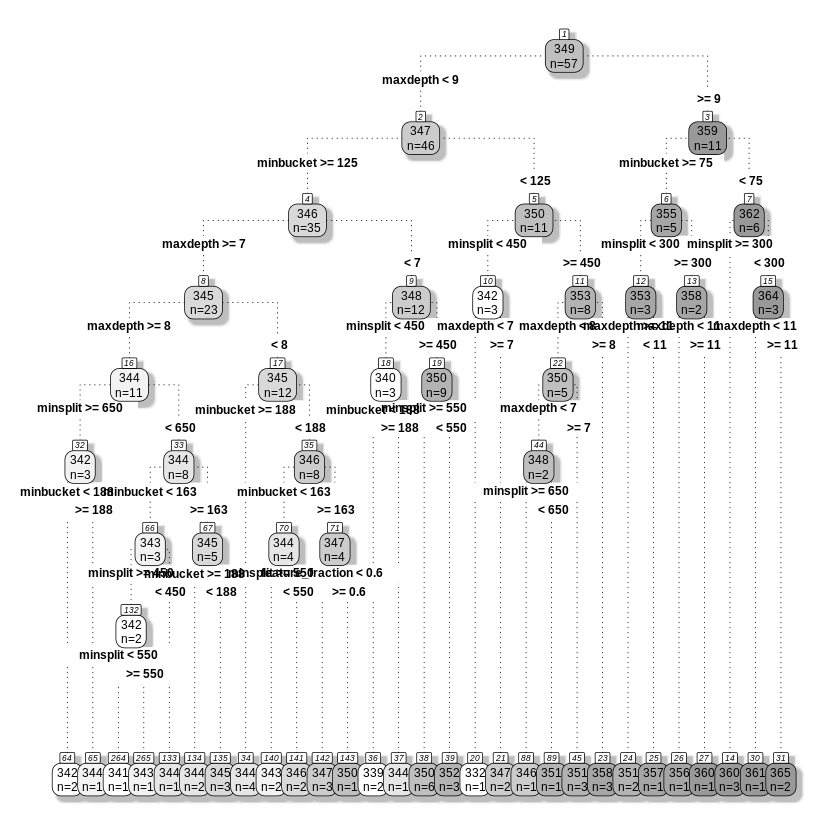

In [20]:
install.packages("rpart.plot")
require(rpart.plot)

# Cargar los resultados consolidados
resultados_kaggle_df <- fread("resultados_kaggle_consolidado.csv")

# Filtrar filas con publicScore valido
resultados_kaggle_df <- resultados_kaggle_df[!is.na(publicScore)]

# Seleccionar las columnas relevantes para el arbol
# Excluimos 'tag' y 'id' para este arbol de decision, ya que se centran en los hiperparametros numéricos.
# 'cp' es fijo a -1, asi que no aporta a la variabilidad.
data_for_tree <- resultados_kaggle_df[, .(feature_fraction, minsplit, minbucket, maxdepth, publicScore)]

# Entrenar un arbol de decision para predecir publicScore
# Usamos cp=0.001 para permitir un arbol mas grande y detallado
# minsplit y minbucket tambien se pueden ajustar para controlar la complejidad
arbol_parametros <- rpart(publicScore ~ feature_fraction + minsplit + minbucket + maxdepth,
                          data = data_for_tree,
                          control = rpart.control(cp = 0.001, minsplit = 2, minbucket = 1))

# Ajustar el tamaño del gráfico y del texto para mejor legibilidad
# Primero, guardar el dispositivo gráfico actual para poder restaurarlo después
# (Esto es útil si hay múltiples llamadas a funciones de gráficos)
old_par <- par(no.readonly = TRUE)

# Aumentar el tamaño de la ventana de trazado y reducir los márgenes
# También se puede usar 'png()' o 'pdf()' para guardar en un archivo con un tamaño específico
par(mfrow = c(1, 1), oma = c(0, 0, 0, 0), mar = c(0, 0, 0, 0) + 0.1)
options(scipen = 999) # para evitar notación científica en los números del plot

rpart.plot(arbol_parametros,
           type = 4, # tipo de grafico
           extra = 1, # mostrar la informacion de la clase
           digits = 2, # numero de decimales
           box.palette = "Grays", # color de las cajas
           branch.lty = 3, # tipo de linea de las ramas
           shadow.col = "gray", # sombra en las cajas
           nn = TRUE, # mostrar el numero de nodo
           cex = 0.6 # Escala el tamaño del texto en el árbol (se puede ajustar)
           )

# Restaurar la configuración gráfica original
par(old_par)

cat("\nEl arbol de decision muestra cómo la combinación de hiperparámetros (feature_fraction, minsplit, minbucket, maxdepth) influye en el publicScore. Cada nodo representa una decision basada en un hiperparámetro, y las hojas muestran el publicScore promedio para esa combinación.\n")



---

